# Random Forest for Conspiracy Detection
## Binary classification (yes/no only)

This notebook implements Random Forest classifier for:
1. **Conspiracy Label Prediction**: **binary (yes/no only)** — "cant_tell" samples are excluded (same as train_and_infer_binary.py)
2. **Model Evaluation**: 5-fold cross-validation on training set
3. **Validation Set Testing**: Evaluation on held-out validation set (100 samples)


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
# Load and merge all features
BASE = Path('../')
PROC = BASE / 'data_processed'
FEAT = BASE / 'features'

# Load base data from data_clean.csv (contains _id, text, conspiracy)
df = pd.read_csv(PROC / 'data_clean.csv')

# Binary classification only: ignore "cant_tell" (same as train_and_infer_binary.py)
n_before = len(df)
df = df[df['conspiracy'].isin(['yes', 'no'])].copy()
n_after = len(df)
print(f"Binary classification: kept only yes/no, excluded {n_before - n_after} 'cant_tell' samples")
print(f"Base data: {df.shape}")
print(f"Base columns: {list(df.columns)}")
print(f"Base data row count: {len(df)}")

# Preserve original columns from data_clean.csv
base_cols = ['_id', 'text', 'conspiracy']
for col in base_cols:
    if col not in df.columns:
        print(f"WARNING: {col} not found in base data!")

# Store base _id values to ensure we only keep these rows
base_ids = set(df['_id'].values)
print(f"Unique _id values in base: {len(base_ids)}")

# Load feature files
feature_files = [
    FEAT / 'lexical_complexity.csv',
    FEAT / 'discourse_markers.csv',
    FEAT / 'sentiment_emotion.csv',
    FEAT / 'token_pos_counts.csv',
    FEAT / 'readability_scores.csv',
    FEAT / 'ma_ttr_mtld_scores.csv',
    FEAT / 'pos_analysis.csv'
]

# Start with base data - this preserves _id, text, conspiracy from data_clean.csv
merged = df.copy()
initial_row_count = len(merged)

# Merge feature files, ensuring we keep original columns from data_clean.csv
# and preserve the exact row count from base data
for feat_file in feature_files:
    if feat_file.exists():
        try:
            feat_df = pd.read_csv(feat_file)
            print(f"\nLoading {feat_file.name}: {feat_df.shape[0]} rows, {feat_df.shape[1]} columns")
            
            if '_id' in merged.columns and '_id' in feat_df.columns:
                # Filter feature file to only include rows with _id in base data
                feat_df_filtered = feat_df[feat_df['_id'].isin(base_ids)].copy()
                print(f"  Filtered to {len(feat_df_filtered)} rows matching base _id values")
                
                # Remove duplicates by _id (keep first occurrence) to prevent row explosion
                initial_filtered_count = len(feat_df_filtered)
                feat_df_filtered = feat_df_filtered.drop_duplicates(subset=['_id'], keep='first')
                if len(feat_df_filtered) < initial_filtered_count:
                    print(f"  Removed {initial_filtered_count - len(feat_df_filtered)} duplicate _id rows (kept first)")
                
                # Drop any columns from feature file that conflict with base_cols (except _id)
                cols_to_drop = [col for col in feat_df_filtered.columns if col in base_cols and col != '_id']
                if cols_to_drop:
                    feat_df_filtered = feat_df_filtered.drop(columns=cols_to_drop)
                    print(f"  Dropped conflicting columns: {cols_to_drop}")
                
                # Merge on _id, keeping all rows from merged (left join)
                merged = merged.merge(feat_df_filtered, on='_id', how='left')
                print(f"  Merged successfully. Merged shape: {merged.shape}")
            else:
                print(f"  Skipped: missing '_id' column")
        except Exception as e:
            print(f"Could not load {feat_file.name}: {e}")

# Verify that original columns from data_clean.csv are still present
for col in base_cols:
    if col not in merged.columns:
        print(f"ERROR: {col} was lost during merge!")

# Verify row count is preserved
if len(merged) != initial_row_count:
    print(f"\nWARNING: Row count changed from {initial_row_count} to {len(merged)}!")
else:
    print(f"\n✓ Row count preserved: {initial_row_count}")

print(f"\nFinal merged shape: {merged.shape}")
print(f"Total columns: {len(merged.columns)}")
print(f"Original columns preserved: {all(col in merged.columns for col in base_cols)}")
print(f"\nColumn breakdown:")
print(f"  Base columns: {base_cols}")
print(f"  Feature columns added: {len(merged.columns) - len(base_cols)}")
print(f"\nFirst few rows (showing base columns + first 5 feature columns):")
feature_cols = [col for col in merged.columns if col not in base_cols][:5]
print(merged[base_cols + feature_cols].head())


Binary classification: kept only yes/no, excluded 671 'cant_tell' samples
Base data: (3011, 3)
Base columns: ['_id', 'text', 'conspiracy']
Base data row count: 3011
Unique _id values in base: 3011

Loading lexical_complexity.csv: 3682 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 7)

Loading discourse_markers.csv: 3682 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 11)

Loading sentiment_emotion.csv: 3682 rows, 5 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 15)

Loading token_pos_counts.csv: 3682 rows, 8 columns
  Filtered to 3011 rows matching base _id values
  Merged successfully. Merged shape: (3011, 22)

Loading readability_scores.csv: 4316 rows, 7 columns
  Filtered to 3531 rows matching base _id values
  Removed 520 duplicate _id rows (kept first)
  Merged successfully. Merged shape: (3011, 28)

Loadin

In [3]:
# Create validation set (100 randomly selected points)
# This validation set will be saved and reused across all ML notebooks
from sklearn.model_selection import train_test_split

VALIDATION_SIZE = 100
VALIDATION_FILE = PROC / 'validation_set_ids.csv'

# Set random seed for reproducibility
np.random.seed(42)

# Check if validation set already exists
if VALIDATION_FILE.exists():
    print("Loading existing validation set...")
    validation_ids_df = pd.read_csv(VALIDATION_FILE)
    validation_ids = set(validation_ids_df['_id'].values)
    print(f"  Loaded {len(validation_ids)} validation IDs from {VALIDATION_FILE.name}")
else:
    print(f"Creating new validation set ({VALIDATION_SIZE} samples)...")
    
    # Use stratified sampling to maintain class distribution
    label_counts = merged['conspiracy'].value_counts()
    print(f"  Class distribution: {dict(label_counts)}")
    
    target_fraction = VALIDATION_SIZE / len(merged)
    
    # Perform stratified split
    train_ids, val_ids = train_test_split(
        merged['_id'].values,
        test_size=target_fraction,
        stratify=merged['conspiracy'].values,
        random_state=42
    )
    
    # Adjust to exactly 100 if needed
    if len(val_ids) > VALIDATION_SIZE:
        val_df_temp = merged[merged['_id'].isin(val_ids)]
        val_ids_adjusted, _ = train_test_split(
            val_ids,
            test_size=VALIDATION_SIZE / len(val_ids),
            stratify=val_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(val_ids_adjusted)
    elif len(val_ids) < VALIDATION_SIZE:
        train_df_temp = merged[merged['_id'].isin(train_ids)]
        additional_needed = VALIDATION_SIZE - len(val_ids)
        additional_ids, _ = train_test_split(
            train_ids,
            test_size=additional_needed / len(train_ids),
            stratify=train_df_temp['conspiracy'].values,
            random_state=42
        )
        validation_ids = set(list(val_ids) + list(additional_ids))
    else:
        validation_ids = set(val_ids)
    
    # Save validation set IDs
    validation_ids_df = pd.DataFrame({'_id': list(validation_ids)})
    validation_ids_df.to_csv(VALIDATION_FILE, index=False)
    print(f"  ✓ Saved validation set to {VALIDATION_FILE.name}")
    print(f"  Validation set size: {len(validation_ids)} samples")

# Display validation set distribution
validation_df = merged[merged['_id'].isin(validation_ids)]
print(f"\nValidation set class distribution:")
print(validation_df['conspiracy'].value_counts().to_dict())

# Remove validation set from training data
train_df = merged[~merged['_id'].isin(validation_ids)].copy()
print(f"\nTraining set size: {len(train_df)} samples")
print(f"Training set class distribution:")
print(train_df['conspiracy'].value_counts().to_dict())

# Update merged to be training data only
merged = train_df.copy()
print(f"\n✓ Updated merged dataframe for training: {merged.shape}")


Loading existing validation set...
  Loaded 100 validation IDs from validation_set_ids.csv

Validation set class distribution:
{'no': 46, 'yes': 36}

Training set size: 2929 samples
Training set class distribution:
{'no': 1662, 'yes': 1267}

✓ Updated merged dataframe for training: (2929, 65)


In [4]:
# Extract numeric features
numeric_cols = merged.select_dtypes(include=[np.number]).columns.tolist()
# Remove _id and other non-feature columns
numeric_cols = [c for c in numeric_cols if c not in ['_id']]
print(f"Number of numeric features: {len(numeric_cols)}")

X = merged[numeric_cols].fillna(0)
print(X.head())
print(f"Feature matrix shape: {X.shape}")
print(f"Missing values: {X.isna().sum().sum()}")


Number of numeric features: 62
        ttr  hapax_ratio  avg_word_len  shannon_entropy  hedge_count  \
0  0.857143     0.714286      4.678571         4.521641            0   
1  0.761905     0.587302      4.920635         5.431811            0   
2  0.818182     0.675325      4.259740         5.867372            0   
3  0.666667     0.555556      4.685185         4.752314            0   
4  0.797101     0.666667      3.797101         5.648025            0   

   certainty_count  discourse_count  passive_count  neg  neu  ...  adp_ratio  \
0                0                0              0  0.0  0.0  ...   0.166667   
1                0                0              1  0.0  0.0  ...   0.134146   
2                0                0              1  0.0  0.0  ...   0.111111   
3                0                0              3  0.0  0.0  ...   0.169231   
4                0                0              0  0.0  0.0  ...   0.080808   

   cconj_ratio  sconj_ratio  num_ratio  part_ratio  int

## Task 1: Conspiracy Label Prediction (binary: yes/no only)


In [5]:
# Task 1: Conspiracy Label Prediction (binary: yes/no only)
y_conspiracy = merged['conspiracy'].copy()
# Filter out any null labels (data is already restricted to yes/no in cell 2)
mask = y_conspiracy.notna()
X_clean = X[mask]
y_clean = y_conspiracy[mask]

print(f"Samples for conspiracy prediction (binary): {len(y_clean)}")
print(f"Label distribution (yes/no only):")
print(y_clean.value_counts())

# Encode labels
le_conspiracy = LabelEncoder()
y_encoded = le_conspiracy.fit_transform(y_clean)
print(f"Encoded labels: {dict(zip(le_conspiracy.classes_, range(len(le_conspiracy.classes_))))}")

# Create pipeline with Random Forest
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=20, 
                                  min_samples_split=5, min_samples_leaf=2,
                                  random_state=42, n_jobs=-1))
])

# 4-fold cross-validation
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

scoring = ['accuracy', 'f1_macro', 'f1_weighted', 'precision_macro', 'recall_macro']
cv_results = cross_validate(pipeline, X_clean, y_encoded, cv=cv, scoring=scoring, n_jobs=-1)

print("\n=== Conspiracy Label Prediction - Binary yes/no (4-fold CV) ===")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Train final model and get feature importance
pipeline.fit(X_clean, y_encoded)
rf_model = pipeline.named_steps['rf']
feature_importance = pd.DataFrame({
    'feature': numeric_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))


Samples for conspiracy prediction (binary): 2929
Label distribution (yes/no only):
conspiracy
no     1662
yes    1267
Name: count, dtype: int64
Encoded labels: {'no': 0, 'yes': 1}

=== Conspiracy Label Prediction - Binary yes/no (4-fold CV) ===
accuracy: 0.5852 (+/- 0.0321)
f1_macro: 0.5439 (+/- 0.0410)
f1_weighted: 0.5624 (+/- 0.0379)
precision_macro: 0.5684 (+/- 0.0398)
recall_macro: 0.5548 (+/- 0.0351)

Top 20 Most Important Features:
                feature  importance
52            adp_ratio    0.031318
59          punct_ratio    0.030650
45           noun_ratio    0.030210
58            aux_ratio    0.029709
2          avg_word_len    0.029563
48            adj_ratio    0.029042
26                 mtld    0.028294
47           verb_ratio    0.027697
25               ma_ttr    0.027615
50           pron_ratio    0.027489
46          propn_ratio    0.026818
1           hapax_ratio    0.026458
51            det_ratio    0.026435
0                   ttr    0.025359
49            adv_

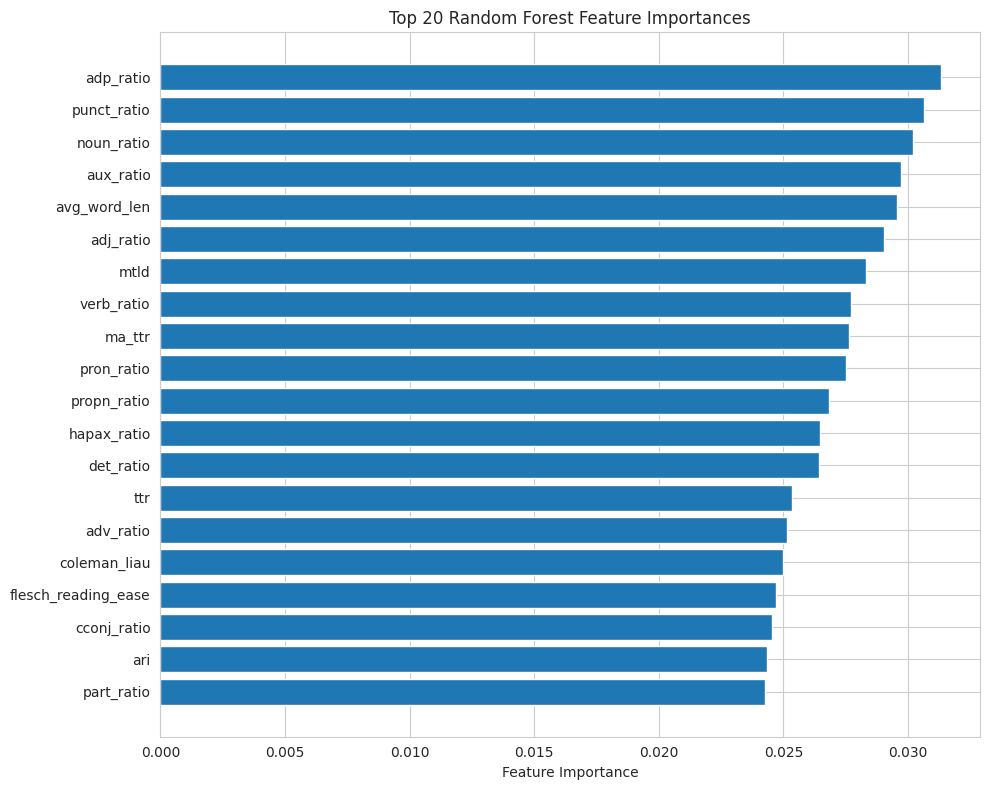


✓ Saved feature importance plot to figures/random_forest_feature_importance.png


In [6]:
# Visualize feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 20 Random Forest Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(BASE / 'figures' / 'random_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ Saved feature importance plot to figures/random_forest_feature_importance.png")


## Final Evaluation on Dev Sets

Evaluate the trained model on **dev_public.jsonl** and **dev_rehydrated.jsonl**.


In [ ]:
# Final evaluation on dev_public.jsonl and dev_rehydrated.jsonl (project root)
DEV_PUBLIC_PATH = BASE / 'data' / 'dev_public.jsonl'
DEV_REHYDRATED_PATH = BASE / 'data' / 'dev_rehydrated.jsonl'

def load_dev_jsonl(path):
    """Load a JSONL dev file into a DataFrame with _id and conspiracy (labels from dev_public)."""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            row = json.loads(line.strip())
            rows.append({'_id': row['_id'], 'conspiracy': row.get('conspiracy')})
    return pd.DataFrame(rows)

def normalize_conspiracy(s):
    """Normalize dev_public labels: 'Yes'->'yes', 'No'->'no', \"Can't tell\"->'cant_tell'."""
    if pd.isna(s) or s is None:
        return s
    s = str(s).strip().lower()
    if "can't tell" in s or s == "cant_tell":
        return 'cant_tell'
    return s

# Load dev_public (has labels)
dev_public_df = load_dev_jsonl(DEV_PUBLIC_PATH) if DEV_PUBLIC_PATH.exists() else pd.DataFrame(columns=['_id', 'conspiracy'])
dev_public_df['conspiracy'] = dev_public_df['conspiracy'].map(normalize_conspiracy)

# Load dev_rehydrated (_ids only; labels come from dev_public)
if DEV_REHYDRATED_PATH.exists():
    with open(DEV_REHYDRATED_PATH) as f:
        dev_rehydrated_df = pd.DataFrame([{'_id': json.loads(line)['_id']} for line in f])
    dev_rehydrated_df = dev_rehydrated_df.merge(dev_public_df[['_id', 'conspiracy']], on='_id', how='left')
else:
    dev_rehydrated_df = pd.DataFrame(columns=['_id', 'conspiracy'])

def merge_dev_features(base_df, name):
    """Merge feature files for a dev base DataFrame; filter to yes/no; return merged, X, y."""
    base_df = base_df[base_df['conspiracy'].isin(['yes', 'no'])].copy()
    if len(base_df) == 0:
        print(f"  {name}: no yes/no samples, skipping.")
        return None, None, None
    dev_ids = set(base_df['_id'].values)
    merged = base_df.copy()
    for feat_file in feature_files:
        if feat_file.exists():
            try:
                feat_df = pd.read_csv(feat_file)
                if '_id' in merged.columns and '_id' in feat_df.columns:
                    feat_df_filtered = feat_df[feat_df['_id'].isin(dev_ids)].copy()
                    feat_df_filtered = feat_df_filtered.drop_duplicates(subset=['_id'], keep='first')
                    cols_to_drop = [c for c in feat_df_filtered.columns if c in base_cols and c != '_id']
                    if cols_to_drop:
                        feat_df_filtered = feat_df_filtered.drop(columns=cols_to_drop)
                    merged = merged.merge(feat_df_filtered, on='_id', how='left')
            except Exception as e:
                print(f"Could not load {feat_file.name} for {name}: {e}")
    merged = merged[merged['conspiracy'].isin(['yes', 'no'])].copy()
    X = merged[numeric_cols].fillna(0)
    y = merged['conspiracy'].copy()
    return merged, X, y

# Build dev sets: list of (name, merged_df, X, y)
dev_sets = []
for path, name in [(DEV_PUBLIC_PATH, 'dev_public'), (DEV_REHYDRATED_PATH, 'dev_rehydrated')]:
    if not path.exists():
        print(f"{name}: file not found {path}, skipping.")
        continue
    if name == 'dev_public':
        base = dev_public_df.copy()
    else:
        base = dev_rehydrated_df.copy()
    merged, X, y = merge_dev_features(base, name)
    if merged is not None:
        dev_sets.append((name, merged, X, y))
        print(f"{name}: {len(merged)} samples (binary yes/no), feature matrix {X.shape}")


In [ ]:
# Evaluate on each dev set (dev_public, dev_rehydrated)
for name, merged, X, y in dev_sets:
    y_encoded = le_conspiracy.transform(y)
    y_pred = pipeline.predict(X)
    y_pred_labels = le_conspiracy.inverse_transform(y_pred)

    print(f"\n{'='*60}")
    print(f"=== {name} ===")
    print(f"{'='*60}")
    print(f"True label distribution:\n{y.value_counts().to_dict()}")
    unique, counts = np.unique(y_pred_labels, return_counts=True)
    print(f"Predicted label distribution:\n{dict(zip(unique, counts))}")

    acc = accuracy_score(y_encoded, y_pred)
    f1_macro = f1_score(y_encoded, y_pred, average='macro')
    f1_weighted = f1_score(y_encoded, y_pred, average='weighted')
    print(f"\nAccuracy: {acc:.4f}  F1 (macro): {f1_macro:.4f}  F1 (weighted): {f1_weighted:.4f}")
    print(f"\nClassification Report:\n{classification_report(y, y_pred_labels, target_names=le_conspiracy.classes_)}")

    cm = confusion_matrix(y_encoded, y_pred)
    print(f"Confusion Matrix (rows=true, cols=pred)\n{cm}")

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le_conspiracy.classes_, yticklabels=le_conspiracy.classes_,
                cbar_kws={'label': 'Count'})
    plt.title(f'Confusion Matrix - {name}', fontsize=14, fontweight='bold')
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout()
    fig_path = BASE / 'figures' / f'validation_confusion_matrix_rf_{name}.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved {fig_path.name}")


In [ ]:
# Sample predictions for each dev set
print("\n=== Sample Predictions ===")
for name, merged, X, y in dev_sets:
    y_pred_labels = le_conspiracy.inverse_transform(pipeline.predict(X))
    n = min(10, len(merged))
    sample_idx = np.random.choice(len(merged), size=n, replace=False)
    results_df = pd.DataFrame({
        '_id': merged.iloc[sample_idx]['_id'].values,
        'true_label': y.iloc[sample_idx].values,
        'predicted_label': y_pred_labels[sample_idx],
        'correct': (y.iloc[sample_idx].values == y_pred_labels[sample_idx])
    })
    print(f"\n--- {name} ---")
    print(results_df.to_string(index=False))
    print(f"  Total: {len(merged)}  Correct: {(y.values == y_pred_labels).sum()}/{len(y)}")
print("\n✓ Final evaluation on dev_public and dev_rehydrated complete!")
